# Guide: AB Testing — From Concept to Conclusion
Learning Goal:

Frame an AB test as a hypothesis test.

Choose the right statistical test based on the metric type (mean vs proportion).

Interpret p-values and confidence intervals to make business recommendations.

Scenario: Testing a New Checkout Page

Business Context:

The e-commerce company ShopSmart redesigned its checkout page to make the process faster and more intuitive.
They ran an AB test for one week:

- Group A (Control) → Old checkout page

- Group B (Variant) → New checkout page

The goal was to determine if the conversion rate (percentage of visitors who completed checkout) increased under the new design.





## Step 1: Define the Hypotheses

We’re testing if the new design improved conversion.


𝐻0: 𝑝𝐴 = 𝑝𝐵 (no difference in conversion rate)

𝐻1: 𝑝𝐵 > 𝑝𝐴 (new design has higher conversion rate)

This is a one-tailed test because the business only cares if the new version performs better.

In [1]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.api import proportion_confint

## Step 2: Load the Data



In [2]:
df = pd.read_csv("data/shop_smart.csv")

In [3]:
df.head()

,group,converted
0,A,0
1,A,1
2,A,1
3,A,0
4,A,0


In [4]:
#Check the group avg 
df['converted'].groupby(df['group']).mean()

group
A    0.13
B    0.16
Name: converted, dtype: float64

## Step 3: Choose and Run the Test

This is a difference in proportions test, so we’ll use statsmodels.stats.proportion.proportions_ztest.

In [5]:
# Count conversions and sample sizes
conversions = df.groupby('group')['converted'].sum()
samples = df.groupby('group')['converted'].count()

count = np.array([conversions['B'], conversions['A']])
nobs = np.array([samples['B'], samples['A']])

# One-sided test (H1: p_B > p_A)
z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print(f"Z-statistic: {z_stat:.3f}, p-value: {p_value:.4f}")


Z-statistic: 1.905, p-value: 0.0284


## Step 4: Estimate Confidence Interval for Difference

We can also compute the 95% confidence interval for the difference in conversion rates.

In [6]:
# Proportion estimates
p_A_hat = conversions['A'] / samples['A']
p_B_hat = conversions['B'] / samples['B']
diff = p_B_hat - p_A_hat

# Confidence intervals (using normal approx)
confint_A = proportion_confint(conversions['A'], samples['A'], alpha=0.05, method='normal')
confint_B = proportion_confint(conversions['B'], samples['B'], alpha=0.05, method='normal')

print(f"Conversion A: {p_A_hat:.3f}  (95% CI: {confint_A})")
print(f"Conversion B: {p_B_hat:.3f}  (95% CI: {confint_B})")
print(f"Difference (B - A): {diff:.3f}")


Conversion A: 0.130  (95% CI: (0.10915608020019973, 0.15084391979980027))
Conversion B: 0.160  (95% CI: (0.13727793879285397, 0.18272206120714604))
Difference (B - A): 0.030


## Step 5: Interpretation 

Estimate of the Effect

Let’s compute the difference in conversion rates:

`15%−12%=3%`

Now, approximate the confidence interval for the difference by subtracting the limits of A’s CI from B’s:

`Lower bound: 13.7−15.1=−1.4%` 

`Upper bound: 18.3−10.1=8.2%`

That gives a rough 95% CI for the difference of about `(-1.4%, +8.2%)`.

- The p-value suggests the difference is statistically significant.

- The CIs show that B’s conversion rate is higher on average.

- The difference in conversion is around +3%, though the uncertainty range crosses close to 0.


## Step 5: Interpretation in Business Terms

P-value interpretation:

`p = 0.028 < 0.05 → reject H₀`.

There is statistically significant evidence that the new checkout page increases conversion.

Confidence interval interpretation:

`Conversion A: ~13% (95% CI: 10.1%–15.1%)`

`Conversion B: ~16% (95% CI: 13.7%–18.3.0%)`

The difference (~3%) is positive and consistent with improved performance.

Business implication:

“Our analysis suggests that the new checkout version (B) performs better than the current one (A).
The improvement in conversion is statistically significant (p = 0.028), with an estimated gain of about 3 percentage points.
While there’s some overlap in the confidence intervals, the overall evidence indicates that the new design likely leads to higher conversions”

------

# Scenario 2: Testing Impact of a New Recommendation Algorithm on Average Order Value (AOV)

Business Context

The same e-commerce company, ShopSmart, has introduced a new recommendation system on the homepage.
They want to check whether it has increased the average order value (AOV) — the average dollar amount customers spend per transaction.

They randomly split visitors into two groups:

- Group A (Control): Old recommendation algorithm

- Group B (Variant): New recommendation algorithm

Analytical Question

Did the new recommendation algorithm lead to a significant increase in the average order value (AOV)?

## Step 1: State the Hypotheses
𝐻0 :𝜇𝐴 = 𝜇𝐵 (no difference in mean AOV)

𝐻1 : 𝜇𝐵 > 𝜇𝐴 (new algorithm increases AOV)

We’re testing whether a new recommendation algorithm on an e-commerce homepage increases how much customers spend per order — the Average Order Value (AOV).

AOV is a continuous metric, and the two groups (A: old algorithm, B: new algorithm) are independent samples.
Because we don’t know the population parameters (like the true standard deviation of all possible transactions), a t-test is appropriate.


This is a one-tailed test — we only care if the new system improves sales.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.stats.api as sms

## Step 2 : Load the data

In [8]:
df_aov = pd.read_csv("data/shop_smart_aov.csv")

df_aov.head()

,group,AOV
0,A,74.076098
1,A,82.342856
2,A,60.611180
3,A,68.365780
4,A,73.992719


In [9]:
df_aov.groupby('group')['AOV'].mean()

group
A    74.395907
B    77.973656
Name: AOV, dtype: float64

## Step 3. Explore the Data and Check Assumptions

Why check normality?
The t-test assumes each group’s data come from a normal distribution.
In practice, for samples above 30, the test is robust to mild deviations from normality — but it’s still good practice to check.

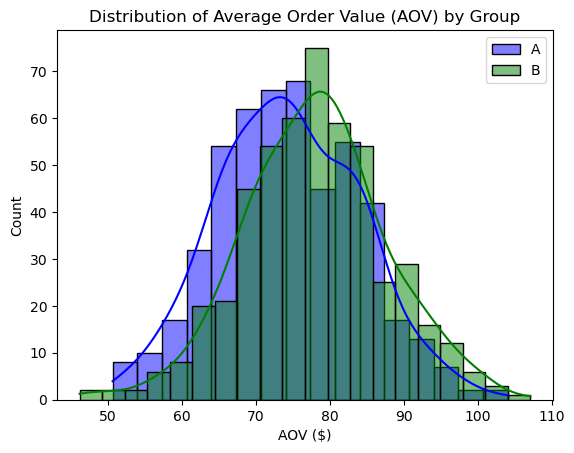

Shapiro p-values -> A: 0.353, B: 0.328


In [12]:

sns.histplot(df_aov[df_aov['group'] == 'A']['AOV'], kde=True, color='blue', label='A')
sns.histplot(df_aov[df_aov['group'] == 'B']['AOV'], kde=True, color='green', label='B')
plt.legend()
plt.title("Distribution of Average Order Value (AOV) by Group")
plt.xlabel("AOV ($)")
plt.show()

# Quick normality check (Shapiro)
_, p_A = stats.shapiro(df_aov[df_aov['group'] == 'A']['AOV'])
_, p_B = stats.shapiro(df_aov[df_aov['group'] == 'B']['AOV'])
print(f"Shapiro p-values -> A: {p_A:.3f}, B: {p_B:.3f}")


Interpretation:

If both p-values > 0.05 → data not significantly different from normal → safe to use t-test.

## Step 4: Conduct the AB Test


In [13]:
t_stat, p_value = stats.ttest_ind(
    df_aov[df_aov['group'] == 'B']['AOV'],
    df_aov[df_aov['group'] == 'A']['AOV'],
    alternative='greater'  # one-tailed test
)

print(f"T-statistic: {t_stat:.3f}, p-value: {p_value:.4f}")


T-statistic: 5.876, p-value: 0.0000


## Step 5: Estimate the Confidence Interval for the Mean Difference

In [14]:


cm = sms.CompareMeans.from_data(
    df_aov[df_aov['group'] == 'B']['AOV'],
    df_aov[df_aov['group'] == 'A']['AOV']
)
ci_low, ci_high = cm.tconfint_diff(alpha=0.05, usevar='pooled')
print(f"95% CI for difference in means (B - A): ({ci_low:.2f}, {ci_high:.2f})")


95% CI for difference in means (B - A): (2.38, 4.77)


## Step 6: Business Interpretation

P-value interpretation:

`p = 0.000 < 0.05 → reject H₀.`

Strong evidence that the new recommendation algorithm increases AOV.

Confidence interval interpretation:

We are 95% confident the true increase in AOV lies between `$2.38 and $4.77`.

Business implication:

“The new recommendation system significantly boosts average order value by about $2.4–$4.8 per customer.
This improvement is statistically significant and likely financially meaningful.
Rolling out the new system could increase daily revenue substantially.”